In [ ]:
pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 7.6 MB/s eta 0:00:00



Data range:
2017-01-31 00:00:00 -> 2025-12-30 00:00:00 | n = 2326
Forecast horizon H = 1
Target aggregation = sum

Train end:   2023-12-31
Validation:  2024-01-01 00:00:00 -> 2024-12-31 00:00:00 | n = 262
OOS:         2025-01-01 00:00:00 -> 2025-12-30 00:00:00 | n = 260

Building expanding 1-step-ahead GARCH forecasts...

========== GARCH vs Benchmarks ==========
               set                    model          MAE         RMSE  \
0        final_oos  GARCH(1,1)-normal | H=1 0.0000965282 0.0001494609   
1        final_oos        22-day mean | H=1 0.0001053588 0.0001577030   
2        final_oos         5-day mean | H=1 0.0000962943 0.0001666006   
3        final_oos              Naive | H=1 0.0000998839 0.0001748453   
4  validation_2024  GARCH(1,1)-normal | H=1 0.0001334980 0.0003182239   
5  validation_2024        22-day mean | H=1 0.0001431777 0.0003271218   
6  validation_2024         5-day mean | H=1 0.0001480959 0.0003354804   
7  validation_2024              Naive | H=1 0.000

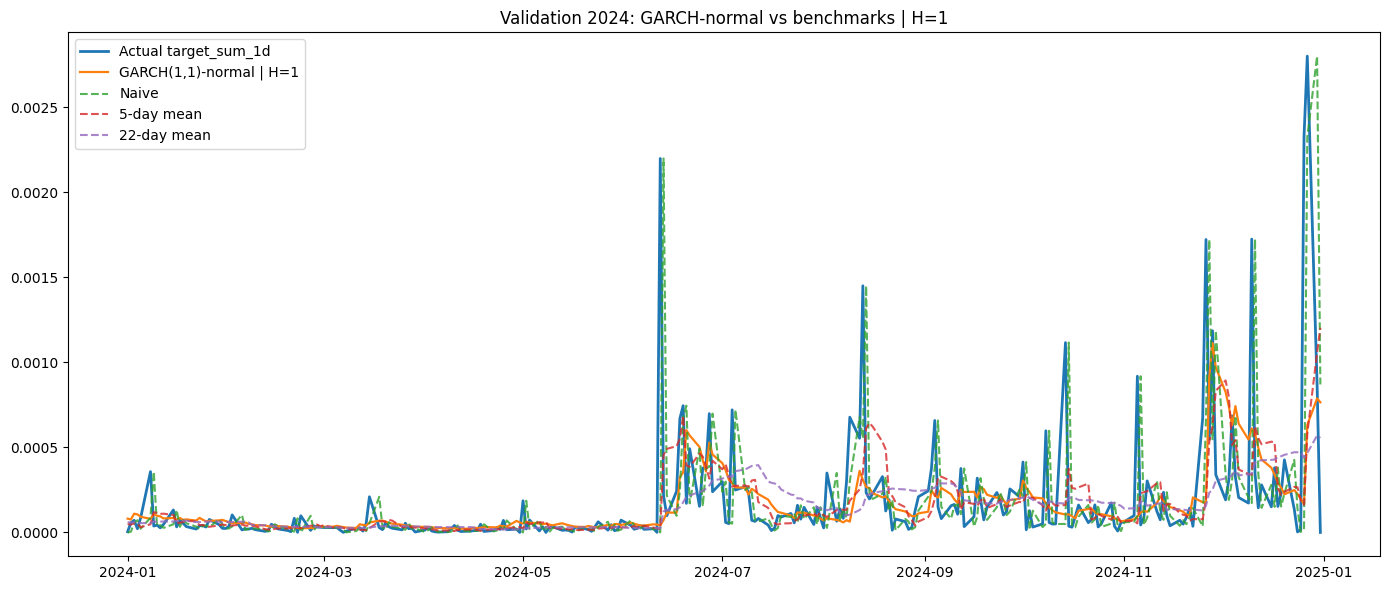

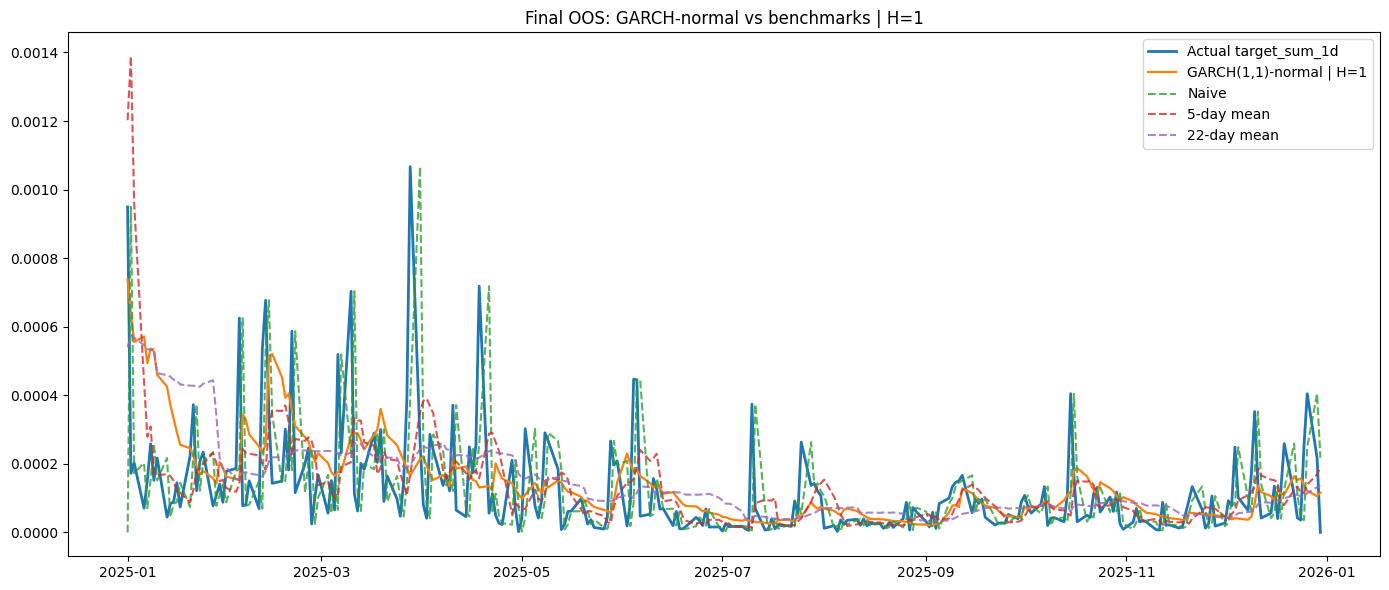

In [ ]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from arch import arch_model

FILE_PATH = "/content/result_hope_8_march.xlsx"
DATE_COL = "Date"
RET_COL = "cnyrub_logret"
RV_COL = "RV_gk"

TRAIN_END = "2023-12-31"
VAL_END   = "2024-12-31"

HORIZON = 1
TARGET_AGG = "sum"
EPS = 1e-12

DIST = "normal"
MEAN_TYPE = "AR"
AR_LAGS = 1
P = 1
Q = 1

pd.set_option("display.float_format", lambda x: f"{x:.10f}")

def load_table(file_path):
    if file_path.lower().endswith((".xlsx", ".xls")):
        return pd.read_excel(file_path)

    attempts = [
        {"sep": ",", "encoding": "utf-8"},
        {"sep": ";", "encoding": "utf-8"},
        {"sep": ",", "encoding": "utf-8-sig"},
        {"sep": ";", "encoding": "utf-8-sig"},
        {"sep": ",", "encoding": "cp1251"},
        {"sep": ";", "encoding": "cp1251"},
        {"sep": ",", "encoding": "cp1252"},
        {"sep": ";", "encoding": "cp1252"},
        {"sep": ",", "encoding": "latin1"},
        {"sep": ";", "encoding": "latin1"},
    ]

    last_error = None
    for params in attempts:
        try:
            df_ = pd.read_csv(file_path, low_memory=False, **params)
            print(f"Loaded CSV with sep={params['sep']!r}, encoding={params['encoding']!r}")
            return df_
        except Exception as e:
            last_error = e

    raise last_error

df = load_table(FILE_PATH)

df[DATE_COL] = pd.to_datetime(df[DATE_COL], dayfirst=True, errors="coerce")
df = df.dropna(subset=[DATE_COL]).sort_values(DATE_COL).reset_index(drop=True)
df = df.replace([np.inf, -np.inf], np.nan)

for col in [RET_COL, RV_COL]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["har_d"] = df[RV_COL]
df["har_w"] = df[RV_COL].rolling(window=5, min_periods=5).mean()
df["har_m"] = df[RV_COL].rolling(window=22, min_periods=22).mean()

def make_forward_target(rv_series, horizon=5, agg="mean"):
    future_vals = pd.concat(
        [rv_series.shift(-i) for i in range(1, horizon + 1)],
        axis=1
    )
    future_vals.columns = [f"RV_t_plus_{i}" for i in range(1, horizon + 1)]

    if agg == "mean":
        target = future_vals.mean(axis=1)
    elif agg == "sum":
        target = future_vals.sum(axis=1)
    else:
        raise ValueError("agg must be either 'mean' or 'sum'")

    return target

TARGET_COL = f"target_{TARGET_AGG}_{HORIZON}d"
df[TARGET_COL] = make_forward_target(df[RV_COL], horizon=HORIZON, agg=TARGET_AGG)

data = df[[DATE_COL, RET_COL, RV_COL, TARGET_COL, "har_d", "har_w", "har_m"]].copy()
data = data.dropna(subset=[RET_COL, RV_COL, TARGET_COL, "har_d", "har_w", "har_m"]).reset_index(drop=True)

data["ret_pct"] = data[RET_COL] * 100.0

print("\nData range:")
print(data[DATE_COL].min(), "->", data[DATE_COL].max(), "| n =", len(data))
print(f"Forecast horizon H = {HORIZON}")
print(f"Target aggregation = {TARGET_AGG}")

val_mask = (data[DATE_COL] > TRAIN_END) & (data[DATE_COL] <= VAL_END)
oos_mask = data[DATE_COL] > VAL_END

val = data.loc[val_mask].copy()
oos = data.loc[oos_mask].copy()

print("\nTrain end:  ", TRAIN_END)
print("Validation: ", val[DATE_COL].min(), "->", val[DATE_COL].max(), "| n =", len(val))
print("OOS:        ", oos[DATE_COL].min(), "->", oos[DATE_COL].max(), "| n =", len(oos))

def qlike(y_true, y_pred, eps=1e-12):
    y_true = np.clip(np.asarray(y_true, dtype=float), eps, None)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), eps, None)
    ratio = y_true / y_pred
    return np.mean(ratio - np.log(ratio) - 1.0)

def calc_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), EPS, None)

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MSE": mean_squared_error(y_true, y_pred),
        "QLIKE": qlike(y_true, y_pred),
    }

def raw_diag(y_pred):
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "raw_min": float(np.min(y_pred)),
        "raw_q01": float(np.quantile(y_pred, 0.01)),
        "raw_q05": float(np.quantile(y_pred, 0.05)),
        "raw_negative_count": int(np.sum(y_pred <= 0)),
        "raw_negative_share": float(np.mean(y_pred <= 0)),
    }

def make_metrics_row(set_name, model_name, y_true, y_pred):
    return {
        "set": set_name,
        "model": model_name,
        **calc_metrics(y_true, y_pred),
        **raw_diag(y_pred)
    }

def fit_garch(series_pct, dist=DIST, mean_type=MEAN_TYPE, lags=AR_LAGS, p=P, q=Q):
    am = arch_model(
        series_pct,
        mean=mean_type,
        lags=lags if mean_type == "AR" else 0,
        vol="GARCH",
        p=p,
        q=q,
        dist=dist,
        rescale=False
    )
    res = am.fit(update_freq=0, disp="off")
    return res

def aggregate_hstep_variance(var_forecast_raw, agg="mean"):

    var_forecast_raw = np.asarray(var_forecast_raw, dtype=float)

    if agg == "mean":
        return np.mean(var_forecast_raw)
    elif agg == "sum":
        return np.sum(var_forecast_raw)
    else:
        raise ValueError("agg must be either 'mean' or 'sum'")

def garch_hstep_expanding_forecast(full_df, eval_mask, horizon=5, agg="mean",
                                   dist=DIST, mean_type=MEAN_TYPE, lags=AR_LAGS, p=P, q=Q):
    preds = []
    pred_dates = []

    eval_positions = full_df.index[eval_mask]

    for pos in eval_positions:
        train_slice = full_df.iloc[:pos + 1].copy()

        if len(train_slice) < 100:
            preds.append(np.nan)
            pred_dates.append(full_df.loc[pos, DATE_COL])
            continue

        try:
            res = fit_garch(
                train_slice["ret_pct"],
                dist=dist,
                mean_type=mean_type,
                lags=lags,
                p=p,
                q=q
            )

            fcst = res.forecast(horizon=horizon, reindex=False)
            var_h_pct2 = fcst.variance.iloc[-1].values[:horizon]
            var_h_raw = var_h_pct2 / (100.0 ** 2)
            pred_h = aggregate_hstep_variance(var_h_raw, agg=agg)

            preds.append(pred_h)
            pred_dates.append(full_df.loc[pos, DATE_COL])

        except Exception:
            preds.append(np.nan)
            pred_dates.append(full_df.loc[pos, DATE_COL])

    return pd.Series(preds, index=pred_dates, name="pred_garch")

print(f"\nBuilding expanding {HORIZON}-step-ahead GARCH forecasts...")
pred_val = garch_hstep_expanding_forecast(
    data, val_mask, horizon=HORIZON, agg=TARGET_AGG
)
pred_oos = garch_hstep_expanding_forecast(
    data, oos_mask, horizon=HORIZON, agg=TARGET_AGG
)

val = val.set_index(DATE_COL)
oos = oos.set_index(DATE_COL)

val["pred_garch"] = pred_val
oos["pred_garch"] = pred_oos

for part in [val, oos]:
    part["pred_naive"] = np.clip(part["har_d"], EPS, None)
    part["pred_mean5"] = np.clip(part["har_w"], EPS, None)
    part["pred_mean22"] = np.clip(part["har_m"], EPS, None)
    part["pred_garch"] = np.clip(part["pred_garch"], EPS, None)

val = val.reset_index()
oos = oos.reset_index()

comparison_rows = []

for set_name, part in [
    ("validation_2024", val),
    ("final_oos", oos),
]:
    tmp = part.dropna(subset=["pred_garch", TARGET_COL]).copy()
    y_true = tmp[TARGET_COL].values

    comparison_rows.append(make_metrics_row(
        set_name, f"GARCH(1,1)-normal | H={HORIZON}", y_true, tmp["pred_garch"].values
    ))
    comparison_rows.append(make_metrics_row(
        set_name, f"Naive | H={HORIZON}", y_true, tmp["pred_naive"].values
    ))
    comparison_rows.append(make_metrics_row(
        set_name, f"5-day mean | H={HORIZON}", y_true, tmp["pred_mean5"].values
    ))
    comparison_rows.append(make_metrics_row(
        set_name, f"22-day mean | H={HORIZON}", y_true, tmp["pred_mean22"].values
    ))

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df[[
    "set", "model", "MAE", "RMSE", "MSE", "QLIKE",
    "raw_min", "raw_q01", "raw_q05", "raw_negative_count", "raw_negative_share"
]]
comparison_df = comparison_df.sort_values(["set", "QLIKE", "RMSE"]).reset_index(drop=True)

print("\n========== GARCH vs Benchmarks ==========")
print(comparison_df.round({
    "MAE": 10,
    "RMSE": 10,
    "MSE": 10,
    "QLIKE": 6,
    "raw_min": 10,
    "raw_q01": 10,
    "raw_q05": 10,
    "raw_negative_share": 6
}))

comparison_pivot = comparison_df.pivot(
    index="model",
    columns="set",
    values=["MAE", "RMSE", "QLIKE", "raw_negative_count"]
)

print("\n========== Pivot table ==========")
print(comparison_pivot.round(10))

train_summary_df = data[data[DATE_COL] <= TRAIN_END].copy()

print(f"\n========== GARCH summary on train up to {TRAIN_END} ==========")
garch_train_res = fit_garch(
    train_summary_df["ret_pct"],
    dist=DIST,
    mean_type=MEAN_TYPE,
    lags=AR_LAGS,
    p=P,
    q=Q
)
print(garch_train_res.summary())

comparison_file = f"garch_normal_H{HORIZON}_{TARGET_AGG}_comparison.csv"
pivot_file = f"garch_normal_H{HORIZON}_{TARGET_AGG}_pivot.csv"
preds_file = f"garch_normal_H{HORIZON}_{TARGET_AGG}_predictions.csv"

comparison_df.to_csv(comparison_file, index=False)
comparison_pivot.to_csv(pivot_file)

val_out = val[[DATE_COL, TARGET_COL, "pred_garch", "pred_naive", "pred_mean5", "pred_mean22"]].copy()
val_out["set"] = "validation_2024"

oos_out = oos[[DATE_COL, TARGET_COL, "pred_garch", "pred_naive", "pred_mean5", "pred_mean22"]].copy()
oos_out["set"] = "final_oos"

all_predictions = pd.concat([val_out, oos_out], axis=0).reset_index(drop=True)
all_predictions.to_csv(preds_file, index=False)

print("\nSaved files:")
print("-", comparison_file)
print("-", pivot_file)
print("-", preds_file)

def plot_preds(df_part, title):
    plt.figure(figsize=(14, 6))
    plt.plot(df_part[DATE_COL], df_part[TARGET_COL], label=f"Actual {TARGET_COL}", linewidth=2)
    plt.plot(df_part[DATE_COL], df_part["pred_garch"], label=f"GARCH(1,1)-normal | H={HORIZON}", linewidth=1.6)
    plt.plot(df_part[DATE_COL], df_part["pred_naive"], label="Naive", linestyle="--", alpha=0.8)
    plt.plot(df_part[DATE_COL], df_part["pred_mean5"], label="5-day mean", linestyle="--", alpha=0.8)
    plt.plot(df_part[DATE_COL], df_part["pred_mean22"], label="22-day mean", linestyle="--", alpha=0.8)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_preds(val, f"Validation 2024: GARCH-normal vs benchmarks | H={HORIZON}")
plot_preds(oos, f"Final OOS: GARCH-normal vs benchmarks | H={HORIZON}")

In [ ]:
pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 37.6 MB/s eta 0:00:00



Data range:
2017-01-31 00:00:00 -> 2025-12-30 00:00:00 | n = 2326
Forecast horizon H = 5
Target aggregation = sum

Train end:   2023-12-31
Validation:  2024-01-01 00:00:00 -> 2024-12-31 00:00:00 | n = 262
OOS:         2025-01-01 00:00:00 -> 2025-12-30 00:00:00 | n = 260

Building expanding 5-step-ahead GARCH forecasts...

========== GARCH vs Benchmarks ==========
               set                    model          MAE         RMSE  \
0        final_oos  GARCH(1,1)-normal | H=5 0.0003500934 0.0005254108   
1        final_oos        22-day mean | H=5 0.0004558802 0.0006019521   
2        final_oos         5-day mean | H=5 0.0004726860 0.0006139673   
3        final_oos              Naive | H=5 0.0004866415 0.0006323577   
4  validation_2024  GARCH(1,1)-normal | H=5 0.0005620910 0.0010628223   
5  validation_2024        22-day mean | H=5 0.0007505519 0.0012883919   
6  validation_2024         5-day mean | H=5 0.0007338204 0.0012769900   
7  validation_2024              Naive | H=5 0.000

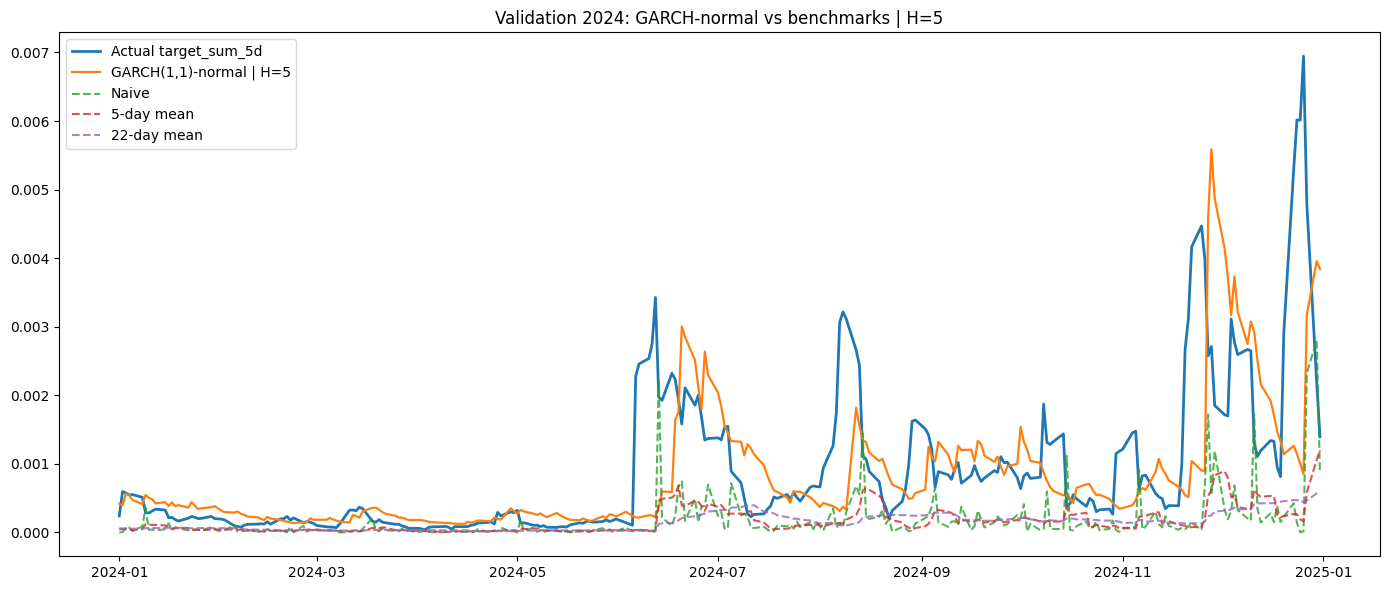

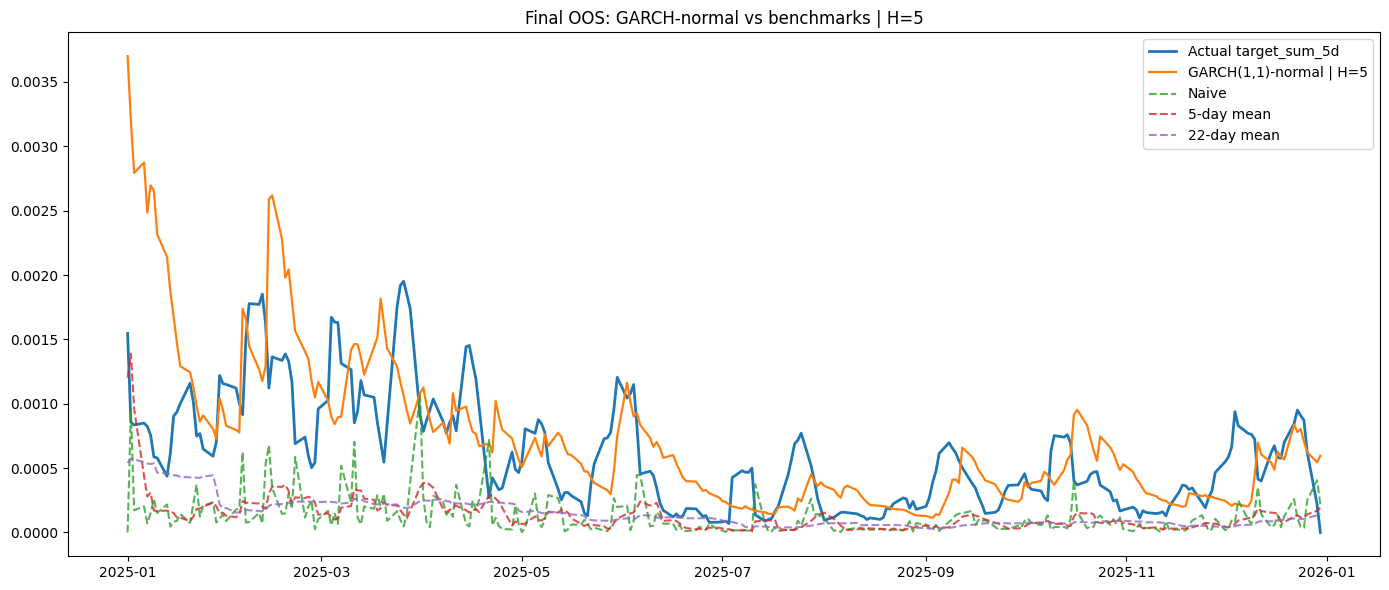

In [ ]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from arch import arch_model

FILE_PATH = "/content/result_hope_8_march.xlsx"
DATE_COL = "Date"
RET_COL = "cnyrub_logret"
RV_COL = "RV_gk"

TRAIN_END = "2023-12-31"
VAL_END   = "2024-12-31"

HORIZON = 5
TARGET_AGG = "sum"
EPS = 1e-12

DIST = "normal"
MEAN_TYPE = "AR"
AR_LAGS = 1
P = 1
Q = 1

pd.set_option("display.float_format", lambda x: f"{x:.10f}")

def load_table(file_path):
    if file_path.lower().endswith((".xlsx", ".xls")):
        return pd.read_excel(file_path)

    attempts = [
        {"sep": ",", "encoding": "utf-8"},
        {"sep": ";", "encoding": "utf-8"},
        {"sep": ",", "encoding": "utf-8-sig"},
        {"sep": ";", "encoding": "utf-8-sig"},
        {"sep": ",", "encoding": "cp1251"},
        {"sep": ";", "encoding": "cp1251"},
        {"sep": ",", "encoding": "cp1252"},
        {"sep": ";", "encoding": "cp1252"},
        {"sep": ",", "encoding": "latin1"},
        {"sep": ";", "encoding": "latin1"},
    ]

    last_error = None
    for params in attempts:
        try:
            df_ = pd.read_csv(file_path, low_memory=False, **params)
            print(f"Loaded CSV with sep={params['sep']!r}, encoding={params['encoding']!r}")
            return df_
        except Exception as e:
            last_error = e

    raise last_error

df = load_table(FILE_PATH)

df[DATE_COL] = pd.to_datetime(df[DATE_COL], dayfirst=True, errors="coerce")
df = df.dropna(subset=[DATE_COL]).sort_values(DATE_COL).reset_index(drop=True)
df = df.replace([np.inf, -np.inf], np.nan)

for col in [RET_COL, RV_COL]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["har_d"] = df[RV_COL]
df["har_w"] = df[RV_COL].rolling(window=5, min_periods=5).mean()
df["har_m"] = df[RV_COL].rolling(window=22, min_periods=22).mean()

def make_forward_target(rv_series, horizon=5, agg="mean"):
    future_vals = pd.concat(
        [rv_series.shift(-i) for i in range(1, horizon + 1)],
        axis=1
    )
    future_vals.columns = [f"RV_t_plus_{i}" for i in range(1, horizon + 1)]

    if agg == "mean":
        target = future_vals.mean(axis=1)
    elif agg == "sum":
        target = future_vals.sum(axis=1)
    else:
        raise ValueError("agg must be either 'mean' or 'sum'")

    return target

TARGET_COL = f"target_{TARGET_AGG}_{HORIZON}d"
df[TARGET_COL] = make_forward_target(df[RV_COL], horizon=HORIZON, agg=TARGET_AGG)

data = df[[DATE_COL, RET_COL, RV_COL, TARGET_COL, "har_d", "har_w", "har_m"]].copy()
data = data.dropna(subset=[RET_COL, RV_COL, TARGET_COL, "har_d", "har_w", "har_m"]).reset_index(drop=True)

data["ret_pct"] = data[RET_COL] * 100.0

print("\nData range:")
print(data[DATE_COL].min(), "->", data[DATE_COL].max(), "| n =", len(data))
print(f"Forecast horizon H = {HORIZON}")
print(f"Target aggregation = {TARGET_AGG}")

val_mask = (data[DATE_COL] > TRAIN_END) & (data[DATE_COL] <= VAL_END)
oos_mask = data[DATE_COL] > VAL_END

val = data.loc[val_mask].copy()
oos = data.loc[oos_mask].copy()

print("\nTrain end:  ", TRAIN_END)
print("Validation: ", val[DATE_COL].min(), "->", val[DATE_COL].max(), "| n =", len(val))
print("OOS:        ", oos[DATE_COL].min(), "->", oos[DATE_COL].max(), "| n =", len(oos))

def qlike(y_true, y_pred, eps=1e-12):
    y_true = np.clip(np.asarray(y_true, dtype=float), eps, None)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), eps, None)
    ratio = y_true / y_pred
    return np.mean(ratio - np.log(ratio) - 1.0)

def calc_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), EPS, None)

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MSE": mean_squared_error(y_true, y_pred),
        "QLIKE": qlike(y_true, y_pred),
    }

def raw_diag(y_pred):
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "raw_min": float(np.min(y_pred)),
        "raw_q01": float(np.quantile(y_pred, 0.01)),
        "raw_q05": float(np.quantile(y_pred, 0.05)),
        "raw_negative_count": int(np.sum(y_pred <= 0)),
        "raw_negative_share": float(np.mean(y_pred <= 0)),
    }

def make_metrics_row(set_name, model_name, y_true, y_pred):
    return {
        "set": set_name,
        "model": model_name,
        **calc_metrics(y_true, y_pred),
        **raw_diag(y_pred)
    }

def fit_garch(series_pct, dist=DIST, mean_type=MEAN_TYPE, lags=AR_LAGS, p=P, q=Q):
    am = arch_model(
        series_pct,
        mean=mean_type,
        lags=lags if mean_type == "AR" else 0,
        vol="GARCH",
        p=p,
        q=q,
        dist=dist,
        rescale=False
    )
    res = am.fit(update_freq=0, disp="off")
    return res

def aggregate_hstep_variance(var_forecast_raw, agg="mean"):

    var_forecast_raw = np.asarray(var_forecast_raw, dtype=float)

    if agg == "mean":
        return np.mean(var_forecast_raw)
    elif agg == "sum":
        return np.sum(var_forecast_raw)
    else:
        raise ValueError("agg must be either 'mean' or 'sum'")

def garch_hstep_expanding_forecast(full_df, eval_mask, horizon=5, agg="mean",
                                   dist=DIST, mean_type=MEAN_TYPE, lags=AR_LAGS, p=P, q=Q):

    preds = []
    pred_dates = []

    eval_positions = full_df.index[eval_mask]

    for pos in eval_positions:
        train_slice = full_df.iloc[:pos + 1].copy()

        if len(train_slice) < 100:
            preds.append(np.nan)
            pred_dates.append(full_df.loc[pos, DATE_COL])
            continue

        try:
            res = fit_garch(
                train_slice["ret_pct"],
                dist=dist,
                mean_type=mean_type,
                lags=lags,
                p=p,
                q=q
            )

            fcst = res.forecast(horizon=horizon, reindex=False)

            var_h_pct2 = fcst.variance.iloc[-1].values[:horizon]

            var_h_raw = var_h_pct2 / (100.0 ** 2)

            pred_h = aggregate_hstep_variance(var_h_raw, agg=agg)

            preds.append(pred_h)
            pred_dates.append(full_df.loc[pos, DATE_COL])

        except Exception:
            preds.append(np.nan)
            pred_dates.append(full_df.loc[pos, DATE_COL])

    return pd.Series(preds, index=pred_dates, name="pred_garch")

print(f"\nBuilding expanding {HORIZON}-step-ahead GARCH forecasts...")
pred_val = garch_hstep_expanding_forecast(
    data, val_mask, horizon=HORIZON, agg=TARGET_AGG
)
pred_oos = garch_hstep_expanding_forecast(
    data, oos_mask, horizon=HORIZON, agg=TARGET_AGG
)
val = val.set_index(DATE_COL)
oos = oos.set_index(DATE_COL)

val["pred_garch"] = pred_val
oos["pred_garch"] = pred_oos

for part in [val, oos]:
    part["pred_naive"] = np.clip(part["har_d"], EPS, None)
    part["pred_mean5"] = np.clip(part["har_w"], EPS, None)
    part["pred_mean22"] = np.clip(part["har_m"], EPS, None)
    part["pred_garch"] = np.clip(part["pred_garch"], EPS, None)

val = val.reset_index()
oos = oos.reset_index()

comparison_rows = []

for set_name, part in [
    ("validation_2024", val),
    ("final_oos", oos),
]:
    tmp = part.dropna(subset=["pred_garch", TARGET_COL]).copy()
    y_true = tmp[TARGET_COL].values

    comparison_rows.append(make_metrics_row(
        set_name, f"GARCH(1,1)-normal | H={HORIZON}", y_true, tmp["pred_garch"].values
    ))
    comparison_rows.append(make_metrics_row(
        set_name, f"Naive | H={HORIZON}", y_true, tmp["pred_naive"].values
    ))
    comparison_rows.append(make_metrics_row(
        set_name, f"5-day mean | H={HORIZON}", y_true, tmp["pred_mean5"].values
    ))
    comparison_rows.append(make_metrics_row(
        set_name, f"22-day mean | H={HORIZON}", y_true, tmp["pred_mean22"].values
    ))

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df[[
    "set", "model", "MAE", "RMSE", "MSE", "QLIKE",
    "raw_min", "raw_q01", "raw_q05", "raw_negative_count", "raw_negative_share"
]]
comparison_df = comparison_df.sort_values(["set", "QLIKE", "RMSE"]).reset_index(drop=True)

print("\n========== GARCH vs Benchmarks ==========")
print(comparison_df.round({
    "MAE": 10,
    "RMSE": 10,
    "MSE": 10,
    "QLIKE": 6,
    "raw_min": 10,
    "raw_q01": 10,
    "raw_q05": 10,
    "raw_negative_share": 6
}))

comparison_pivot = comparison_df.pivot(
    index="model",
    columns="set",
    values=["MAE", "RMSE", "QLIKE", "raw_negative_count"]
)

print("\n========== Pivot table ==========")
print(comparison_pivot.round(10))

train_summary_df = data[data[DATE_COL] <= TRAIN_END].copy()

print(f"\n========== GARCH summary on train up to {TRAIN_END} ==========")
garch_train_res = fit_garch(
    train_summary_df["ret_pct"],
    dist=DIST,
    mean_type=MEAN_TYPE,
    lags=AR_LAGS,
    p=P,
    q=Q
)
print(garch_train_res.summary())

comparison_file = f"garch_normal_H{HORIZON}_{TARGET_AGG}_comparison.csv"
pivot_file = f"garch_normal_H{HORIZON}_{TARGET_AGG}_pivot.csv"
preds_file = f"garch_normal_H{HORIZON}_{TARGET_AGG}_predictions.csv"

comparison_df.to_csv(comparison_file, index=False)
comparison_pivot.to_csv(pivot_file)

val_out = val[[DATE_COL, TARGET_COL, "pred_garch", "pred_naive", "pred_mean5", "pred_mean22"]].copy()
val_out["set"] = "validation_2024"

oos_out = oos[[DATE_COL, TARGET_COL, "pred_garch", "pred_naive", "pred_mean5", "pred_mean22"]].copy()
oos_out["set"] = "final_oos"

all_predictions = pd.concat([val_out, oos_out], axis=0).reset_index(drop=True)
all_predictions.to_csv(preds_file, index=False)

print("\nSaved files:")
print("-", comparison_file)
print("-", pivot_file)
print("-", preds_file)

def plot_preds(df_part, title):
    plt.figure(figsize=(14, 6))
    plt.plot(df_part[DATE_COL], df_part[TARGET_COL], label=f"Actual {TARGET_COL}", linewidth=2)
    plt.plot(df_part[DATE_COL], df_part["pred_garch"], label=f"GARCH(1,1)-normal | H={HORIZON}", linewidth=1.6)
    plt.plot(df_part[DATE_COL], df_part["pred_naive"], label="Naive", linestyle="--", alpha=0.8)
    plt.plot(df_part[DATE_COL], df_part["pred_mean5"], label="5-day mean", linestyle="--", alpha=0.8)
    plt.plot(df_part[DATE_COL], df_part["pred_mean22"], label="22-day mean", linestyle="--", alpha=0.8)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_preds(val, f"Validation 2024: GARCH-normal vs benchmarks | H={HORIZON}")
plot_preds(oos, f"Final OOS: GARCH-normal vs benchmarks | H={HORIZON}")


Data range:
2017-01-31 00:00:00 -> 2025-12-29 00:00:00 | n = 2325
Forecast horizon H = 10
Target aggregation = mean

Train end:   2023-12-31
Validation:  2024-01-01 00:00:00 -> 2024-12-31 00:00:00 | n = 262
OOS:         2025-01-01 00:00:00 -> 2025-12-29 00:00:00 | n = 259

Building expanding 10-step-ahead GARCH forecasts...

========== GARCH vs Benchmarks ==========
               set                     model          MAE         RMSE  \
0        final_oos  GARCH(1,1)-normal | H=10 0.0000662010 0.0001044575   
1        final_oos        22-day mean | H=10 0.0000712911 0.0001063994   
2        final_oos         5-day mean | H=10 0.0000733417 0.0001375635   
3        final_oos              Naive | H=10 0.0000885723 0.0001421744   
4  validation_2024  GARCH(1,1)-normal | H=10 0.0001133536 0.0001832394   
5  validation_2024        22-day mean | H=10 0.0000970058 0.0001551862   
6  validation_2024         5-day mean | H=10 0.0001191126 0.0001984845   
7  validation_2024              Naive 

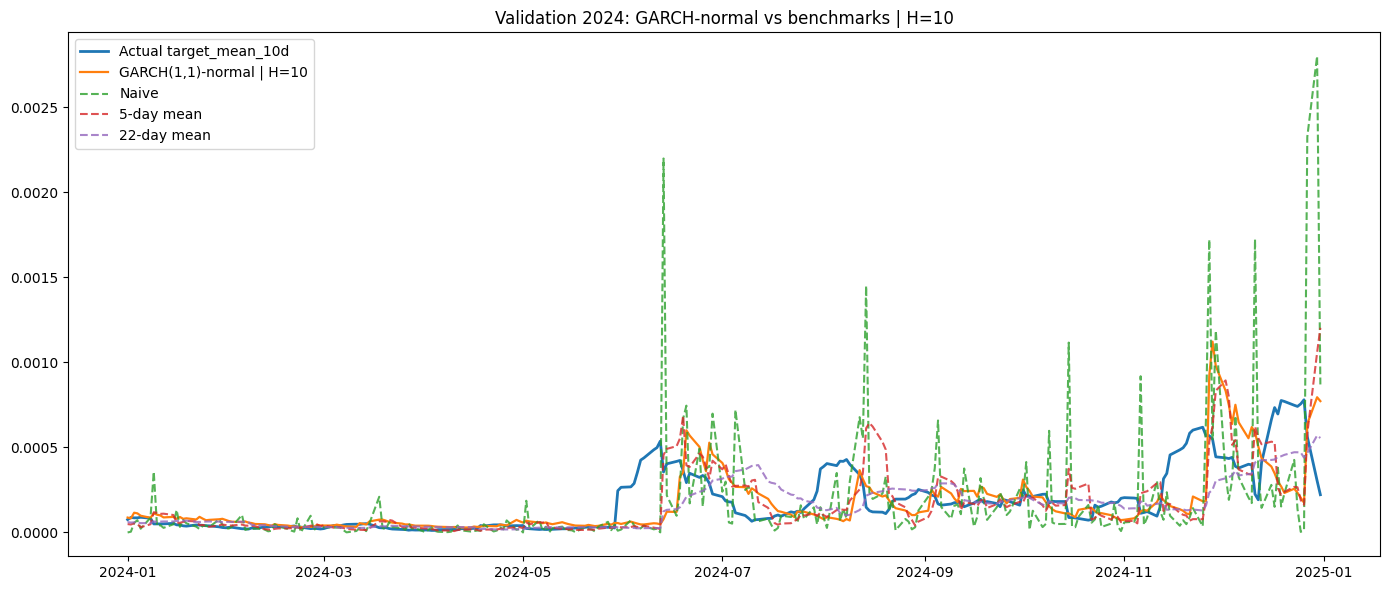

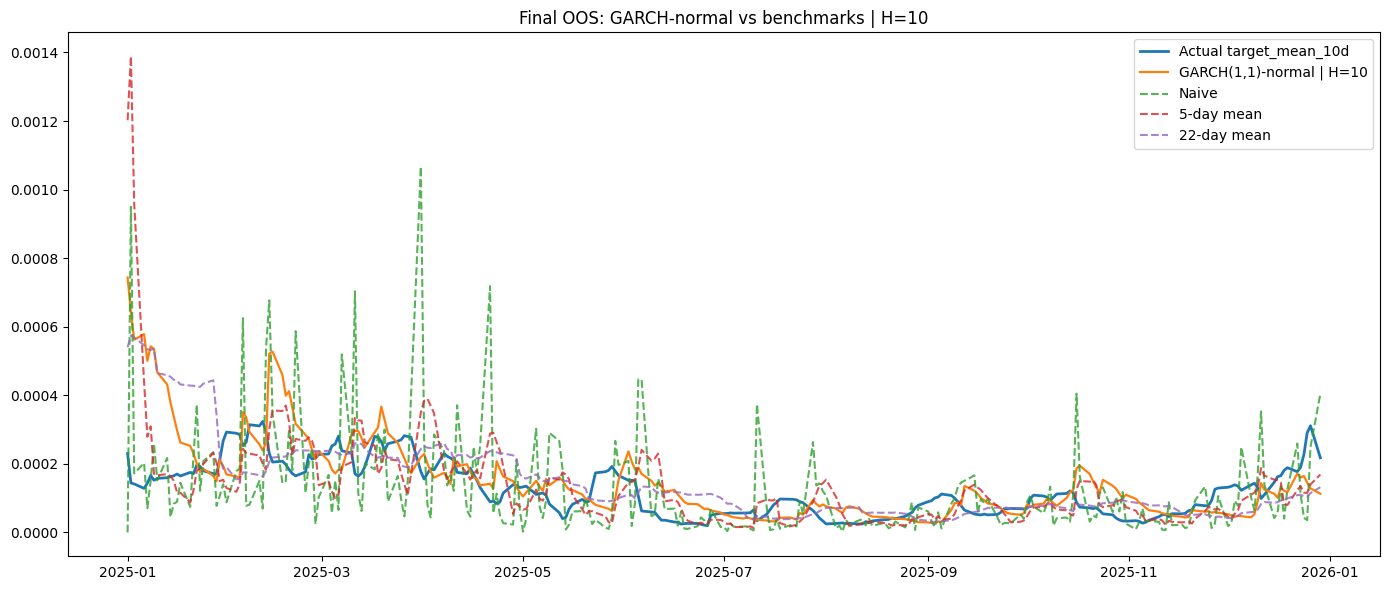

In [ ]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from arch import arch_model

FILE_PATH = "/content/result_hope_8_march.xlsx"
DATE_COL = "Date"
RET_COL = "cnyrub_logret"
RV_COL = "RV_gk"

TRAIN_END = "2023-12-31"
VAL_END   = "2024-12-31"

HORIZON = 10
TARGET_AGG = "mean"
EPS = 1e-12

DIST = "normal"
MEAN_TYPE = "AR"
AR_LAGS = 1
P = 1
Q = 1

pd.set_option("display.float_format", lambda x: f"{x:.10f}")

def load_table(file_path):
    if file_path.lower().endswith((".xlsx", ".xls")):
        return pd.read_excel(file_path)

    attempts = [
        {"sep": ",", "encoding": "utf-8"},
        {"sep": ";", "encoding": "utf-8"},
        {"sep": ",", "encoding": "utf-8-sig"},
        {"sep": ";", "encoding": "utf-8-sig"},
        {"sep": ",", "encoding": "cp1251"},
        {"sep": ";", "encoding": "cp1251"},
        {"sep": ",", "encoding": "cp1252"},
        {"sep": ";", "encoding": "cp1252"},
        {"sep": ",", "encoding": "latin1"},
        {"sep": ";", "encoding": "latin1"},
    ]

    last_error = None
    for params in attempts:
        try:
            df_ = pd.read_csv(file_path, low_memory=False, **params)
            print(f"Loaded CSV with sep={params['sep']!r}, encoding={params['encoding']!r}")
            return df_
        except Exception as e:
            last_error = e

    raise last_error

df = load_table(FILE_PATH)

df[DATE_COL] = pd.to_datetime(df[DATE_COL], dayfirst=True, errors="coerce")
df = df.dropna(subset=[DATE_COL]).sort_values(DATE_COL).reset_index(drop=True)
df = df.replace([np.inf, -np.inf], np.nan)

for col in [RET_COL, RV_COL]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["har_d"] = df[RV_COL]
df["har_w"] = df[RV_COL].rolling(window=5, min_periods=5).mean()
df["har_m"] = df[RV_COL].rolling(window=22, min_periods=22).mean()

def make_forward_target(rv_series, horizon=5, agg="mean"):
    future_vals = pd.concat(
        [rv_series.shift(-i) for i in range(1, horizon + 1)],
        axis=1
    )
    future_vals.columns = [f"RV_t_plus_{i}" for i in range(1, horizon + 1)]

    if agg == "mean":
        target = future_vals.mean(axis=1)
    elif agg == "sum":
        target = future_vals.sum(axis=1)
    else:
        raise ValueError("agg must be either 'mean' or 'sum'")

    return target

TARGET_COL = f"target_{TARGET_AGG}_{HORIZON}d"
df[TARGET_COL] = make_forward_target(df[RV_COL], horizon=HORIZON, agg=TARGET_AGG)

data = df[[DATE_COL, RET_COL, RV_COL, TARGET_COL, "har_d", "har_w", "har_m"]].copy()
data = data.dropna(subset=[RET_COL, RV_COL, TARGET_COL, "har_d", "har_w", "har_m"]).reset_index(drop=True)

data["ret_pct"] = data[RET_COL] * 100.0

print("\nData range:")
print(data[DATE_COL].min(), "->", data[DATE_COL].max(), "| n =", len(data))
print(f"Forecast horizon H = {HORIZON}")
print(f"Target aggregation = {TARGET_AGG}")

val_mask = (data[DATE_COL] > TRAIN_END) & (data[DATE_COL] <= VAL_END)
oos_mask = data[DATE_COL] > VAL_END

val = data.loc[val_mask].copy()
oos = data.loc[oos_mask].copy()

print("\nTrain end:  ", TRAIN_END)
print("Validation: ", val[DATE_COL].min(), "->", val[DATE_COL].max(), "| n =", len(val))
print("OOS:        ", oos[DATE_COL].min(), "->", oos[DATE_COL].max(), "| n =", len(oos))

def qlike(y_true, y_pred, eps=1e-12):
    y_true = np.clip(np.asarray(y_true, dtype=float), eps, None)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), eps, None)
    ratio = y_true / y_pred
    return np.mean(ratio - np.log(ratio) - 1.0)

def calc_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), EPS, None)

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MSE": mean_squared_error(y_true, y_pred),
        "QLIKE": qlike(y_true, y_pred),
    }

def raw_diag(y_pred):
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "raw_min": float(np.min(y_pred)),
        "raw_q01": float(np.quantile(y_pred, 0.01)),
        "raw_q05": float(np.quantile(y_pred, 0.05)),
        "raw_negative_count": int(np.sum(y_pred <= 0)),
        "raw_negative_share": float(np.mean(y_pred <= 0)),
    }

def make_metrics_row(set_name, model_name, y_true, y_pred):
    return {
        "set": set_name,
        "model": model_name,
        **calc_metrics(y_true, y_pred),
        **raw_diag(y_pred)
    }

def fit_garch(series_pct, dist=DIST, mean_type=MEAN_TYPE, lags=AR_LAGS, p=P, q=Q):
    am = arch_model(
        series_pct,
        mean=mean_type,
        lags=lags if mean_type == "AR" else 0,
        vol="GARCH",
        p=p,
        q=q,
        dist=dist,
        rescale=False
    )
    res = am.fit(update_freq=0, disp="off")
    return res

def aggregate_hstep_variance(var_forecast_raw, agg="mean"):

    var_forecast_raw = np.asarray(var_forecast_raw, dtype=float)

    if agg == "mean":
        return np.mean(var_forecast_raw)
    elif agg == "sum":
        return np.sum(var_forecast_raw)
    else:
        raise ValueError("agg must be either 'mean' or 'sum'")

def garch_hstep_expanding_forecast(full_df, eval_mask, horizon=5, agg="mean",
                                   dist=DIST, mean_type=MEAN_TYPE, lags=AR_LAGS, p=P, q=Q):

    preds = []
    pred_dates = []

    eval_positions = full_df.index[eval_mask]

    for pos in eval_positions:
        train_slice = full_df.iloc[:pos + 1].copy()

        if len(train_slice) < 100:
            preds.append(np.nan)
            pred_dates.append(full_df.loc[pos, DATE_COL])
            continue

        try:
            res = fit_garch(
                train_slice["ret_pct"],
                dist=dist,
                mean_type=mean_type,
                lags=lags,
                p=p,
                q=q
            )

            fcst = res.forecast(horizon=horizon, reindex=False)

            var_h_pct2 = fcst.variance.iloc[-1].values[:horizon]
            var_h_raw = var_h_pct2 / (100.0 ** 2)

            pred_h = aggregate_hstep_variance(var_h_raw, agg=agg)

            preds.append(pred_h)
            pred_dates.append(full_df.loc[pos, DATE_COL])

        except Exception:
            preds.append(np.nan)
            pred_dates.append(full_df.loc[pos, DATE_COL])

    return pd.Series(preds, index=pred_dates, name="pred_garch")

print(f"\nBuilding expanding {HORIZON}-step-ahead GARCH forecasts...")
pred_val = garch_hstep_expanding_forecast(
    data, val_mask, horizon=HORIZON, agg=TARGET_AGG
)
pred_oos = garch_hstep_expanding_forecast(
    data, oos_mask, horizon=HORIZON, agg=TARGET_AGG
)
val = val.set_index(DATE_COL)
oos = oos.set_index(DATE_COL)

val["pred_garch"] = pred_val
oos["pred_garch"] = pred_oos

for part in [val, oos]:
    part["pred_naive"] = np.clip(part["har_d"], EPS, None)
    part["pred_mean5"] = np.clip(part["har_w"], EPS, None)
    part["pred_mean22"] = np.clip(part["har_m"], EPS, None)
    part["pred_garch"] = np.clip(part["pred_garch"], EPS, None)

val = val.reset_index()
oos = oos.reset_index()

comparison_rows = []

for set_name, part in [
    ("validation_2024", val),
    ("final_oos", oos),
]:
    tmp = part.dropna(subset=["pred_garch", TARGET_COL]).copy()
    y_true = tmp[TARGET_COL].values

    comparison_rows.append(make_metrics_row(
        set_name, f"GARCH(1,1)-normal | H={HORIZON}", y_true, tmp["pred_garch"].values
    ))
    comparison_rows.append(make_metrics_row(
        set_name, f"Naive | H={HORIZON}", y_true, tmp["pred_naive"].values
    ))
    comparison_rows.append(make_metrics_row(
        set_name, f"5-day mean | H={HORIZON}", y_true, tmp["pred_mean5"].values
    ))
    comparison_rows.append(make_metrics_row(
        set_name, f"22-day mean | H={HORIZON}", y_true, tmp["pred_mean22"].values
    ))

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df[[
    "set", "model", "MAE", "RMSE", "MSE", "QLIKE",
    "raw_min", "raw_q01", "raw_q05", "raw_negative_count", "raw_negative_share"
]]
comparison_df = comparison_df.sort_values(["set", "QLIKE", "RMSE"]).reset_index(drop=True)

print("\n========== GARCH vs Benchmarks ==========")
print(comparison_df.round({
    "MAE": 10,
    "RMSE": 10,
    "MSE": 10,
    "QLIKE": 6,
    "raw_min": 10,
    "raw_q01": 10,
    "raw_q05": 10,
    "raw_negative_share": 6
}))

comparison_pivot = comparison_df.pivot(
    index="model",
    columns="set",
    values=["MAE", "RMSE", "QLIKE", "raw_negative_count"]
)

print("\n========== Pivot table ==========")
print(comparison_pivot.round(10))

train_summary_df = data[data[DATE_COL] <= TRAIN_END].copy()

print(f"\n========== GARCH summary on train up to {TRAIN_END} ==========")
garch_train_res = fit_garch(
    train_summary_df["ret_pct"],
    dist=DIST,
    mean_type=MEAN_TYPE,
    lags=AR_LAGS,
    p=P,
    q=Q
)
print(garch_train_res.summary())

comparison_file = f"garch_normal_H{HORIZON}_{TARGET_AGG}_comparison.csv"
pivot_file = f"garch_normal_H{HORIZON}_{TARGET_AGG}_pivot.csv"
preds_file = f"garch_normal_H{HORIZON}_{TARGET_AGG}_predictions.csv"

comparison_df.to_csv(comparison_file, index=False)
comparison_pivot.to_csv(pivot_file)

val_out = val[[DATE_COL, TARGET_COL, "pred_garch", "pred_naive", "pred_mean5", "pred_mean22"]].copy()
val_out["set"] = "validation_2024"

oos_out = oos[[DATE_COL, TARGET_COL, "pred_garch", "pred_naive", "pred_mean5", "pred_mean22"]].copy()
oos_out["set"] = "final_oos"

all_predictions = pd.concat([val_out, oos_out], axis=0).reset_index(drop=True)
all_predictions.to_csv(preds_file, index=False)

print("\nSaved files:")
print("-", comparison_file)
print("-", pivot_file)
print("-", preds_file)

def plot_preds(df_part, title):
    plt.figure(figsize=(14, 6))
    plt.plot(df_part[DATE_COL], df_part[TARGET_COL], label=f"Actual {TARGET_COL}", linewidth=2)
    plt.plot(df_part[DATE_COL], df_part["pred_garch"], label=f"GARCH(1,1)-normal | H={HORIZON}", linewidth=1.6)
    plt.plot(df_part[DATE_COL], df_part["pred_naive"], label="Naive", linestyle="--", alpha=0.8)
    plt.plot(df_part[DATE_COL], df_part["pred_mean5"], label="5-day mean", linestyle="--", alpha=0.8)
    plt.plot(df_part[DATE_COL], df_part["pred_mean22"], label="22-day mean", linestyle="--", alpha=0.8)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_preds(val, f"Validation 2024: GARCH-normal vs benchmarks | H={HORIZON}")
plot_preds(oos, f"Final OOS: GARCH-normal vs benchmarks | H={HORIZON}")


Data range:
2017-01-31 00:00:00 -> 2025-12-29 00:00:00 | n = 2325
Forecast horizon H = 22
Target aggregation = mean

Train end:   2023-12-31
Validation:  2024-01-01 00:00:00 -> 2024-12-31 00:00:00 | n = 262
OOS:         2025-01-01 00:00:00 -> 2025-12-29 00:00:00 | n = 259

Building expanding 22-step-ahead GARCH forecasts...

========== GARCH vs Benchmarks ==========
               set                     model          MAE         RMSE  \
0        final_oos  GARCH(1,1)-normal | H=22 0.0000639040 0.0001025245   
1        final_oos        22-day mean | H=22 0.0000607448 0.0000956247   
2        final_oos         5-day mean | H=22 0.0000701039 0.0001344171   
3        final_oos              Naive | H=22 0.0000878785 0.0001401972   
4  validation_2024  GARCH(1,1)-normal | H=22 0.0001104809 0.0001566129   
5  validation_2024        22-day mean | H=22 0.0000888884 0.0001359341   
6  validation_2024         5-day mean | H=22 0.0001181680 0.0001786426   
7  validation_2024              Naive 

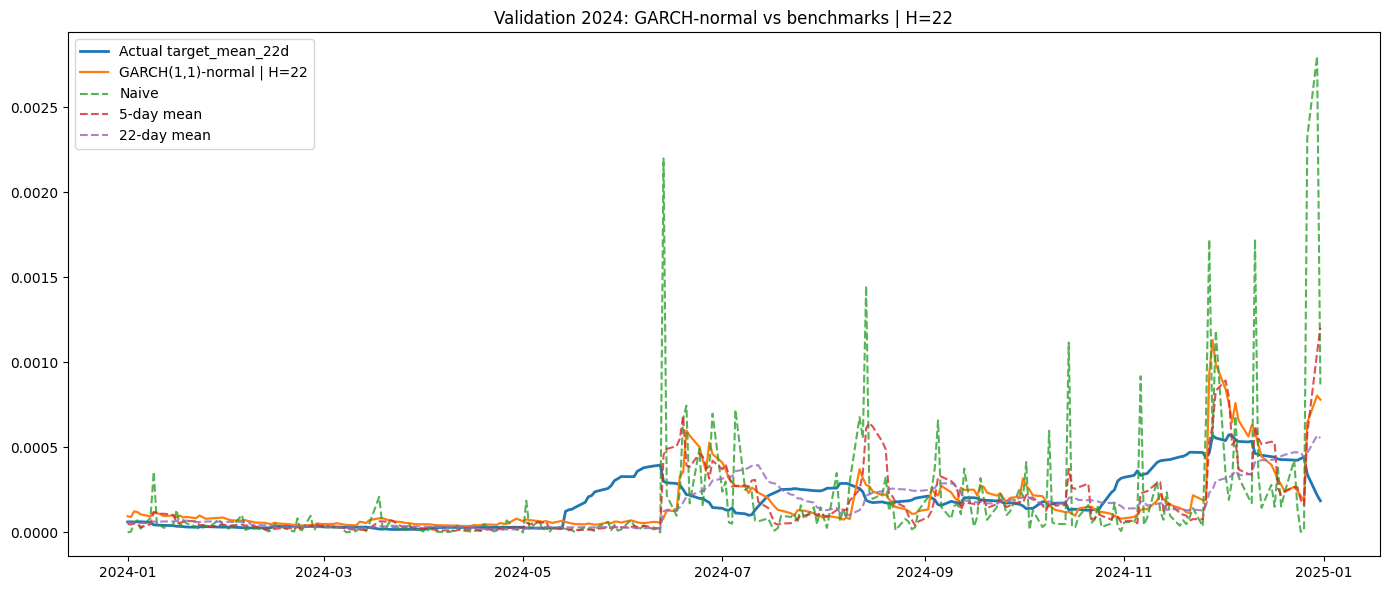

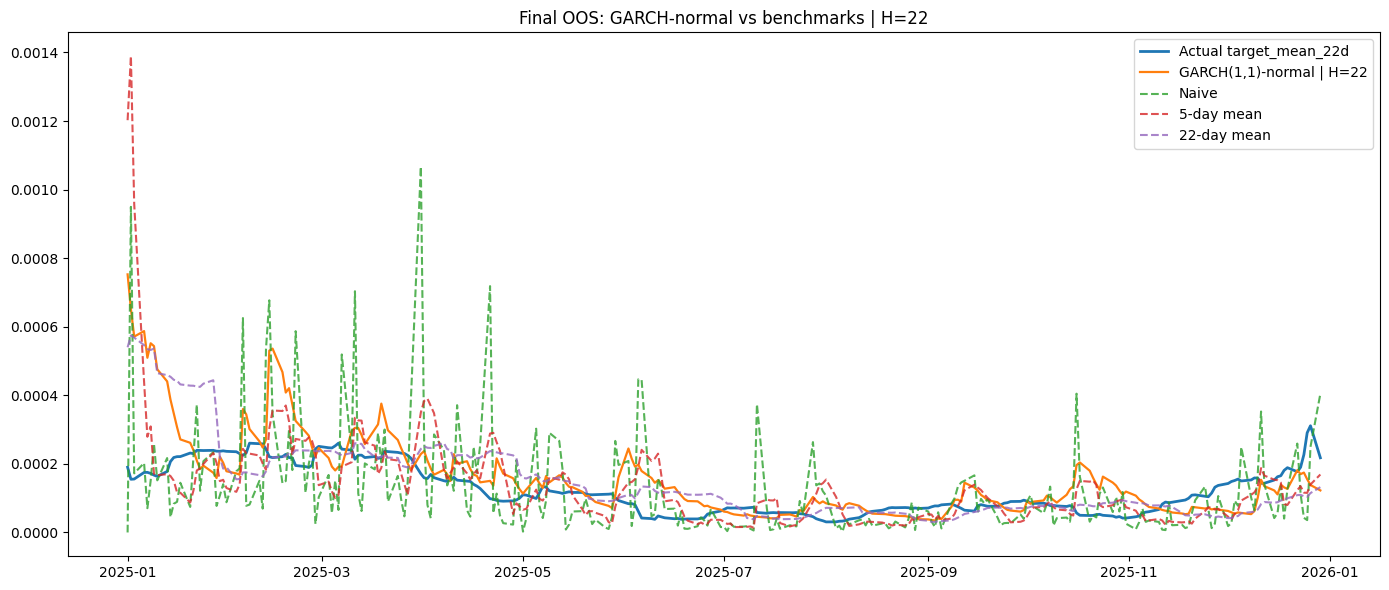

In [ ]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from arch import arch_model

FILE_PATH = "/content/result_hope_8_march.xlsx"
DATE_COL = "Date"
RET_COL = "cnyrub_logret"
RV_COL = "RV_gk"

TRAIN_END = "2023-12-31"
VAL_END   = "2024-12-31"

HORIZON = 22
TARGET_AGG = "mean"
EPS = 1e-12

DIST = "normal"
MEAN_TYPE = "AR"
AR_LAGS = 1
P = 1
Q = 1

pd.set_option("display.float_format", lambda x: f"{x:.10f}")

def load_table(file_path):
    if file_path.lower().endswith((".xlsx", ".xls")):
        return pd.read_excel(file_path)

    attempts = [
        {"sep": ",", "encoding": "utf-8"},
        {"sep": ";", "encoding": "utf-8"},
        {"sep": ",", "encoding": "utf-8-sig"},
        {"sep": ";", "encoding": "utf-8-sig"},
        {"sep": ",", "encoding": "cp1251"},
        {"sep": ";", "encoding": "cp1251"},
        {"sep": ",", "encoding": "cp1252"},
        {"sep": ";", "encoding": "cp1252"},
        {"sep": ",", "encoding": "latin1"},
        {"sep": ";", "encoding": "latin1"},
    ]

    last_error = None
    for params in attempts:
        try:
            df_ = pd.read_csv(file_path, low_memory=False, **params)
            print(f"Loaded CSV with sep={params['sep']!r}, encoding={params['encoding']!r}")
            return df_
        except Exception as e:
            last_error = e

    raise last_error

df = load_table(FILE_PATH)

df[DATE_COL] = pd.to_datetime(df[DATE_COL], dayfirst=True, errors="coerce")
df = df.dropna(subset=[DATE_COL]).sort_values(DATE_COL).reset_index(drop=True)
df = df.replace([np.inf, -np.inf], np.nan)

for col in [RET_COL, RV_COL]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["har_d"] = df[RV_COL]
df["har_w"] = df[RV_COL].rolling(window=5, min_periods=5).mean()
df["har_m"] = df[RV_COL].rolling(window=22, min_periods=22).mean()

def make_forward_target(rv_series, horizon=5, agg="mean"):
    future_vals = pd.concat(
        [rv_series.shift(-i) for i in range(1, horizon + 1)],
        axis=1
    )
    future_vals.columns = [f"RV_t_plus_{i}" for i in range(1, horizon + 1)]

    if agg == "mean":
        target = future_vals.mean(axis=1)
    elif agg == "sum":
        target = future_vals.sum(axis=1)
    else:
        raise ValueError("agg must be either 'mean' or 'sum'")

    return target

TARGET_COL = f"target_{TARGET_AGG}_{HORIZON}d"
df[TARGET_COL] = make_forward_target(df[RV_COL], horizon=HORIZON, agg=TARGET_AGG)

data = df[[DATE_COL, RET_COL, RV_COL, TARGET_COL, "har_d", "har_w", "har_m"]].copy()
data = data.dropna(subset=[RET_COL, RV_COL, TARGET_COL, "har_d", "har_w", "har_m"]).reset_index(drop=True)

data["ret_pct"] = data[RET_COL] * 100.0

print("\nData range:")
print(data[DATE_COL].min(), "->", data[DATE_COL].max(), "| n =", len(data))
print(f"Forecast horizon H = {HORIZON}")
print(f"Target aggregation = {TARGET_AGG}")

val_mask = (data[DATE_COL] > TRAIN_END) & (data[DATE_COL] <= VAL_END)
oos_mask = data[DATE_COL] > VAL_END

val = data.loc[val_mask].copy()
oos = data.loc[oos_mask].copy()

print("\nTrain end:  ", TRAIN_END)
print("Validation: ", val[DATE_COL].min(), "->", val[DATE_COL].max(), "| n =", len(val))
print("OOS:        ", oos[DATE_COL].min(), "->", oos[DATE_COL].max(), "| n =", len(oos))

def qlike(y_true, y_pred, eps=1e-12):
    y_true = np.clip(np.asarray(y_true, dtype=float), eps, None)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), eps, None)
    ratio = y_true / y_pred
    return np.mean(ratio - np.log(ratio) - 1.0)

def calc_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), EPS, None)

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MSE": mean_squared_error(y_true, y_pred),
        "QLIKE": qlike(y_true, y_pred),
    }

def raw_diag(y_pred):
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "raw_min": float(np.min(y_pred)),
        "raw_q01": float(np.quantile(y_pred, 0.01)),
        "raw_q05": float(np.quantile(y_pred, 0.05)),
        "raw_negative_count": int(np.sum(y_pred <= 0)),
        "raw_negative_share": float(np.mean(y_pred <= 0)),
    }

def make_metrics_row(set_name, model_name, y_true, y_pred):
    return {
        "set": set_name,
        "model": model_name,
        **calc_metrics(y_true, y_pred),
        **raw_diag(y_pred)
    }

def fit_garch(series_pct, dist=DIST, mean_type=MEAN_TYPE, lags=AR_LAGS, p=P, q=Q):
    am = arch_model(
        series_pct,
        mean=mean_type,
        lags=lags if mean_type == "AR" else 0,
        vol="GARCH",
        p=p,
        q=q,
        dist=dist,
        rescale=False
    )
    res = am.fit(update_freq=0, disp="off")
    return res

def aggregate_hstep_variance(var_forecast_raw, agg="mean"):

    var_forecast_raw = np.asarray(var_forecast_raw, dtype=float)

    if agg == "mean":
        return np.mean(var_forecast_raw)
    elif agg == "sum":
        return np.sum(var_forecast_raw)
    else:
        raise ValueError("agg must be either 'mean' or 'sum'")

def garch_hstep_expanding_forecast(full_df, eval_mask, horizon=5, agg="mean",
                                   dist=DIST, mean_type=MEAN_TYPE, lags=AR_LAGS, p=P, q=Q):

    preds = []
    pred_dates = []

    eval_positions = full_df.index[eval_mask]

    for pos in eval_positions:
        train_slice = full_df.iloc[:pos + 1].copy()

        if len(train_slice) < 100:
            preds.append(np.nan)
            pred_dates.append(full_df.loc[pos, DATE_COL])
            continue

        try:
            res = fit_garch(
                train_slice["ret_pct"],
                dist=dist,
                mean_type=mean_type,
                lags=lags,
                p=p,
                q=q
            )

            fcst = res.forecast(horizon=horizon, reindex=False)
            var_h_pct2 = fcst.variance.iloc[-1].values[:horizon]
            var_h_raw = var_h_pct2 / (100.0 ** 2)

            pred_h = aggregate_hstep_variance(var_h_raw, agg=agg)

            preds.append(pred_h)
            pred_dates.append(full_df.loc[pos, DATE_COL])

        except Exception:
            preds.append(np.nan)
            pred_dates.append(full_df.loc[pos, DATE_COL])

    return pd.Series(preds, index=pred_dates, name="pred_garch")

print(f"\nBuilding expanding {HORIZON}-step-ahead GARCH forecasts...")
pred_val = garch_hstep_expanding_forecast(
    data, val_mask, horizon=HORIZON, agg=TARGET_AGG
)
pred_oos = garch_hstep_expanding_forecast(
    data, oos_mask, horizon=HORIZON, agg=TARGET_AGG
)
val = val.set_index(DATE_COL)
oos = oos.set_index(DATE_COL)

val["pred_garch"] = pred_val
oos["pred_garch"] = pred_oos
for part in [val, oos]:
    part["pred_naive"] = np.clip(part["har_d"], EPS, None)
    part["pred_mean5"] = np.clip(part["har_w"], EPS, None)
    part["pred_mean22"] = np.clip(part["har_m"], EPS, None)
    part["pred_garch"] = np.clip(part["pred_garch"], EPS, None)

val = val.reset_index()
oos = oos.reset_index()

comparison_rows = []

for set_name, part in [
    ("validation_2024", val),
    ("final_oos", oos),
]:
    tmp = part.dropna(subset=["pred_garch", TARGET_COL]).copy()
    y_true = tmp[TARGET_COL].values

    comparison_rows.append(make_metrics_row(
        set_name, f"GARCH(1,1)-normal | H={HORIZON}", y_true, tmp["pred_garch"].values
    ))
    comparison_rows.append(make_metrics_row(
        set_name, f"Naive | H={HORIZON}", y_true, tmp["pred_naive"].values
    ))
    comparison_rows.append(make_metrics_row(
        set_name, f"5-day mean | H={HORIZON}", y_true, tmp["pred_mean5"].values
    ))
    comparison_rows.append(make_metrics_row(
        set_name, f"22-day mean | H={HORIZON}", y_true, tmp["pred_mean22"].values
    ))

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df[[
    "set", "model", "MAE", "RMSE", "MSE", "QLIKE",
    "raw_min", "raw_q01", "raw_q05", "raw_negative_count", "raw_negative_share"
]]
comparison_df = comparison_df.sort_values(["set", "QLIKE", "RMSE"]).reset_index(drop=True)

print("\n========== GARCH vs Benchmarks ==========")
print(comparison_df.round({
    "MAE": 10,
    "RMSE": 10,
    "MSE": 10,
    "QLIKE": 6,
    "raw_min": 10,
    "raw_q01": 10,
    "raw_q05": 10,
    "raw_negative_share": 6
}))

comparison_pivot = comparison_df.pivot(
    index="model",
    columns="set",
    values=["MAE", "RMSE", "QLIKE", "raw_negative_count"]
)

print("\n========== Pivot table ==========")
print(comparison_pivot.round(10))

train_summary_df = data[data[DATE_COL] <= TRAIN_END].copy()

print(f"\n========== GARCH summary on train up to {TRAIN_END} ==========")
garch_train_res = fit_garch(
    train_summary_df["ret_pct"],
    dist=DIST,
    mean_type=MEAN_TYPE,
    lags=AR_LAGS,
    p=P,
    q=Q
)
print(garch_train_res.summary())

comparison_file = f"garch_normal_H{HORIZON}_{TARGET_AGG}_comparison.csv"
pivot_file = f"garch_normal_H{HORIZON}_{TARGET_AGG}_pivot.csv"
preds_file = f"garch_normal_H{HORIZON}_{TARGET_AGG}_predictions.csv"

comparison_df.to_csv(comparison_file, index=False)
comparison_pivot.to_csv(pivot_file)

val_out = val[[DATE_COL, TARGET_COL, "pred_garch", "pred_naive", "pred_mean5", "pred_mean22"]].copy()
val_out["set"] = "validation_2024"

oos_out = oos[[DATE_COL, TARGET_COL, "pred_garch", "pred_naive", "pred_mean5", "pred_mean22"]].copy()
oos_out["set"] = "final_oos"

all_predictions = pd.concat([val_out, oos_out], axis=0).reset_index(drop=True)
all_predictions.to_csv(preds_file, index=False)

print("\nSaved files:")
print("-", comparison_file)
print("-", pivot_file)
print("-", preds_file)


def plot_preds(df_part, title):
    plt.figure(figsize=(14, 6))
    plt.plot(df_part[DATE_COL], df_part[TARGET_COL], label=f"Actual {TARGET_COL}", linewidth=2)
    plt.plot(df_part[DATE_COL], df_part["pred_garch"], label=f"GARCH(1,1)-normal | H={HORIZON}", linewidth=1.6)
    plt.plot(df_part[DATE_COL], df_part["pred_naive"], label="Naive", linestyle="--", alpha=0.8)
    plt.plot(df_part[DATE_COL], df_part["pred_mean5"], label="5-day mean", linestyle="--", alpha=0.8)
    plt.plot(df_part[DATE_COL], df_part["pred_mean22"], label="22-day mean", linestyle="--", alpha=0.8)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_preds(val, f"Validation 2024: GARCH-normal vs benchmarks | H={HORIZON}")
plot_preds(oos, f"Final OOS: GARCH-normal vs benchmarks | H={HORIZON}")